# **Evaluación 1 - Machine Learning**


## **Sección 1**

Genere las siguientes imágenes de manera sintética. \\

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

In [8]:
# Import some libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from google.colab.patches import cv2_imshow

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Ejercicio 1 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1Z3yNgkQVFJyaCRyTzkjFhIB_3kxqs61q/view?usp=drive_link). \\
**NOTA:** En la salida de la celda puede encontrar el tamaño de la imagen final.

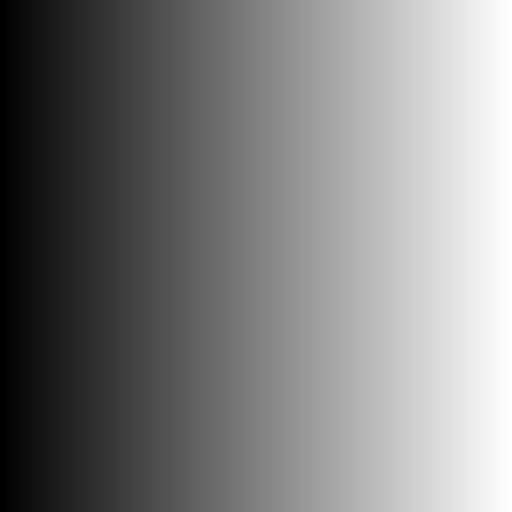

Dimensiones de la imagen: (512, 512)


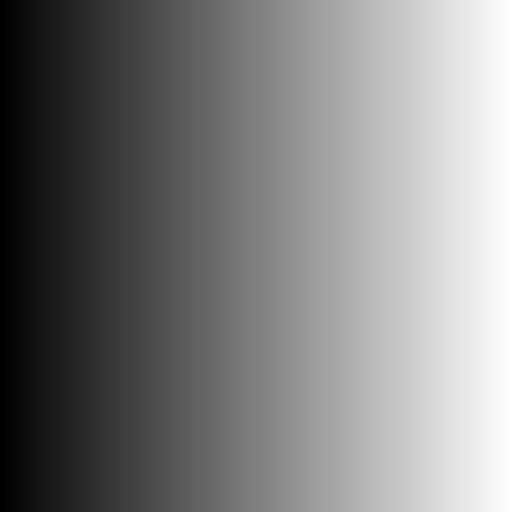

In [3]:
width = 512
height = 512

fila_gradiente = np.linspace(0, 255, width, dtype=np.uint8)

imagen_final = np.tile(fila_gradiente, (height, 1))

print(f"Dimensiones de la imagen: {imagen_final.shape}")
cv2_imshow(imagen_final)

### **Ejercicio 2 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/13z0tvGYD-37_PuHOqoRWHGGmGq7xxvU7/view?usp=drive_link).

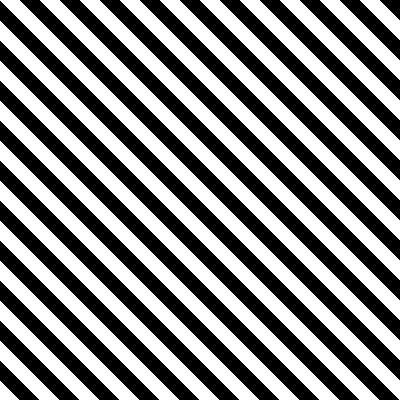

Dimensiones de la imagen: (400, 400)


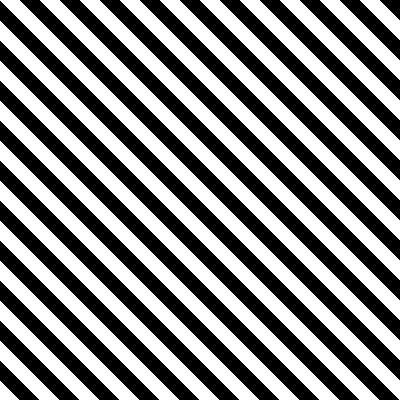

In [4]:
size = 400
ancho_franja = 20

y, x = np.indices((size, size))

diagonal_invertida = (x - y) + size

imagen_diagonales_rotada = np.where((diagonal_invertida // ancho_franja) % 2 == 0, 255, 0).astype(np.uint8)

print(f"Dimensiones de la imagen: {imagen_diagonales_rotada.shape}")
cv2_imshow(imagen_diagonales_rotada)

## **Sección 2**

Genere las siguientes imágenes usando recorridos por píxeles a partir de [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view?usp=sharing)  y [bengal_tiger.jpg](https://drive.google.com/file/d/1oz8CWUjN7UBNJNq1XOxqzwmYcJRTRmxr/view?usp=sharing)

**NOTA:** NO USE FUNCIONES ESPECIALES DE LIBRERÍAS DE PROCESAMIENTO DE IMÁGENES (CV, PIL, SKIMAGE) MÁS QUE PARA CARGARLAS O GUARDARLAS. USE SÓLO NUMPY Y OPERACIONES CON ARREGLOS

### **Ejercicio 3 (C = 1.6)**

Genere la siguiente animación [resultado](https://drive.google.com/file/d/1jSNhV2CYdm6-E5wuo7o5wE-b2J-_mEil/view?usp=drive_link).

In [10]:

img_lena = cv2.imread('/content/drive/MyDrive/Semestre9/MachineLearning/Lenna.png')
img_tiger = cv2.imread('/content/drive/MyDrive/Semestre9/MachineLearning/Tigre.jpg')

# Esto se quedo porque en un momento no me estaban cargando bien, a veces colab causa muchos problemas para encontrar archivos
if img_lena is None or img_tiger is None:
    print("ERROR: No se encontró alguna de las imágenes.")
    print(f"Check Lena: {img_lena is not None}")
    print(f"Check Tiger: {img_tiger is not None}")
else:
    # Preparar dimensiones (Recorté con Slicing de Numpy para igualar tamaños)
    h = min(img_lena.shape[0], img_tiger.shape[0])
    w = min(img_lena.shape[1], img_tiger.shape[1])

    img1 = img_lena[:h, :w].astype(np.float32)
    img2 = img_tiger[:h, :w].astype(np.float32)

    frames = []
    n_frames = 30 # Aumentado para mayor suavidad

    # Transición
    for i in range(n_frames + 1):
        alpha = i / n_frames
        # Fórmula de mezcla: (1-a)*A + a*B
        mix = (1.0 - alpha) * img1 + alpha * img2

        # Convertir a uint8 y a RGB (formato estándar para GIFs)
        frame = mix.astype(np.uint8)
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # 5. Generar la transición de REGRESO
    regreso = frames[::-1][1:-1]

    frames_totales = frames + regreso

    nombre_archivo = 'Ejercicio_03.gif'
    imageio.mimsave(nombre_archivo, frames_totales, fps=20, loop=0)

    print(f"GIF infinito generado como '{nombre_archivo}'")

GIF infinito generado como 'Ejercicio_03.gif'


### **Ejercicio 4 (C = 1.0)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/1UX2Y8Q2xWy5ej0hl_r1B-fKAQ8SX5DI1/view?usp=drive_link).

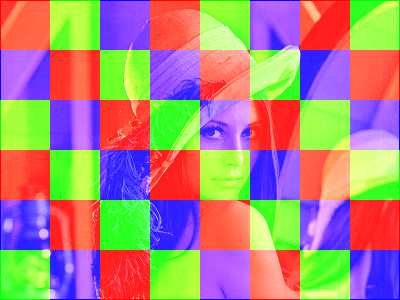

Dimensiones de Lena: 512x512x3
Dimensiones finales: (512, 512, 3)


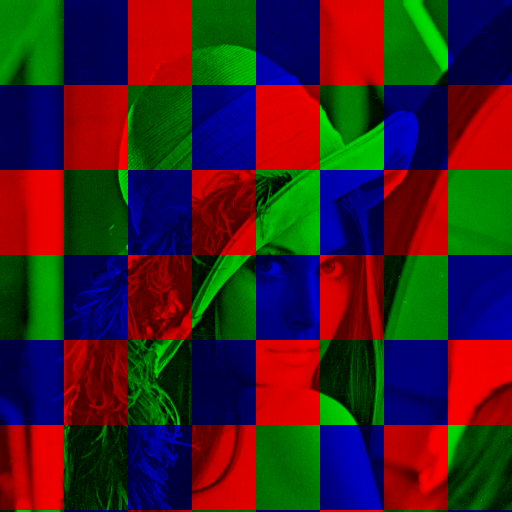

In [6]:
img_lena = cv2.imread('/content/drive/MyDrive/Semestre9/MachineLearning/Lenna.png')

if img_lena is None:
    print("Error: No se pudo cargar la imagen 'lena.png'.")
else:
    h, w, c = img_lena.shape
    print(f"Dimensiones de Lena: {h}x{w}x{c}")

    num_divisiones = 8 # Número de cuadros por lado
    alto_cuadro = h // 6 # Aqui me di cuenta que el solo habia 6 cuadros en vertical
    ancho_cuadro = w // num_divisiones

    color_rojo = np.array([1.0, 0.0, 0.0], dtype=np.float32)
    color_azul = np.array([0.0, 1.0, 0.0], dtype=np.float32)
    color_verde = np.array([0.0, 0.0, 1.0], dtype=np.float32)

    patron_colores = [color_azul, color_rojo, color_verde]

    imagen_float = img_lena.astype(np.float32) / 255.0
    imagen_resultado = imagen_float.copy()

    # Iterar sobre la cuadrícula
    for f in range(num_divisiones):
        for c_idx in range(num_divisiones):
            indice_color = (f + c_idx) % 3
            color_cuadro = patron_colores[indice_color]

            # Definir los límites del cuadro actual usando 'slicing'
            f_inicio = f * alto_cuadro
            f_fin = f_inicio + alto_cuadro
            c_inicio = c_idx * ancho_cuadro
            c_fin = c_inicio + ancho_cuadro

            imagen_resultado[f_inicio:f_fin, c_inicio:c_fin, :] *= color_cuadro

    # Convertir de vuelta a uint8 y mostrar
    imagen_final = (imagen_resultado * 255).astype(np.uint8)

    print(f"Dimensiones finales: {imagen_final.shape}")
    cv2_imshow(imagen_final)


### **Ejercicio 5 (C = 0.7)**

Genere la siguiente imagen [resultado](https://drive.google.com/file/d/10jxoa_muSn6bxsDBy7Vw88wz1oirMiRH/view?usp=drive_link)

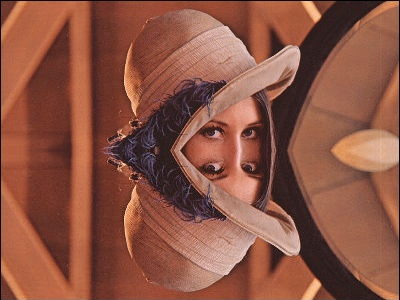

Punto de corte: 300
Nueva altura total: 600


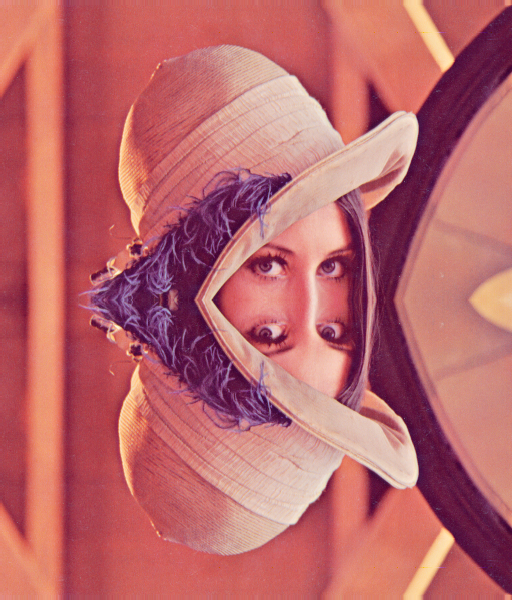

In [7]:
img_original = cv2.imread('/content/drive/MyDrive/Semestre9/MachineLearning/Lenna.png')

if img_original is None:
    print("Error: No se pudo cargar la imagen.")
else:
    h, w, c = img_original.shape

    punto_corte = 300

    punto_corte = min(max(0, punto_corte), h)

    # Tomamos desde la fila 0 hasta la fila 'punto_corte'
    parte_superior = img_original[:punto_corte, :, :]

    # Reflejamos esa parte
    reflejo = parte_superior[::-1, :, :]

    # Unimos
    imagen_espejo_horizontal = np.concatenate((parte_superior, reflejo), axis=0)

    print(f"Punto de corte: {punto_corte}")
    print(f"Nueva altura total: {imagen_espejo_horizontal.shape[0]}")
    cv2_imshow(imagen_espejo_horizontal)